## mnist_explore.ipynb
Download MNIST handwritten digit data and start exploring...

In [79]:
import sys, os
sys.path.append(os.path.abspath(".."))
import src.NNN as MyNN
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (1.5, 1.5)
#import sys
#print(sys.executable) # check correct .venv?

x_train.shape: (60000, 28, 28)     y_train.shape: (60000,)
x_test.shape : (10000, 28, 28)      y_test.shape: (10000,)
x_train.dtype: uint8     y_train.dtype: uint8


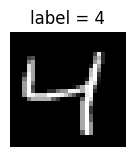

In [82]:
# load data using keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# check the shape of arrays
print('x_train.shape:', x_train.shape, '    y_train.shape:', y_train.shape)
print('x_test.shape :', x_test.shape, '     y_test.shape:', y_test.shape)
print('x_train.dtype:', x_train.dtype, '    y_train.dtype:', y_train.dtype)

# show one item
def draw_1_OLD(imgs, labels, index):
    plt.imshow(imgs[index], cmap="gray")
    plt.title(f"label = {labels[index]}")
    plt.axis("off")
    plt.show()
draw_1_OLD(x_train, y_train, 2)

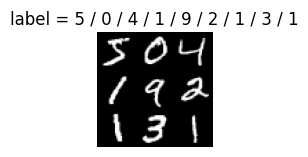

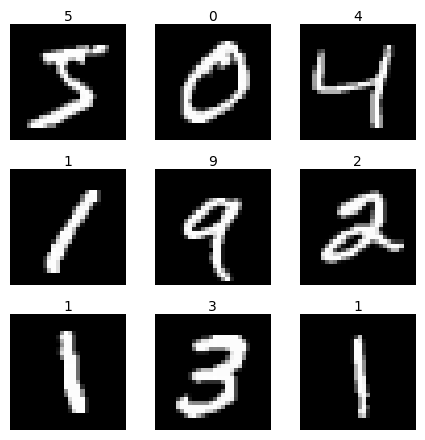

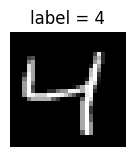

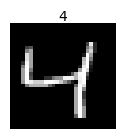

In [4]:
def draw_grid_pixels(imgs : np.ndarray, labels, i : np.ndarray, shape=None):
    pxrow, pxcol = len(imgs[0]), len(imgs[0][0])
    pixels = np.zeros((shape[0] * pxrow, shape[1] * pxcol), dtype=imgs.dtype)

    index = 0
    for r in range(shape[0]):
        for c in range(shape[1]):
            pixels[r*pxrow:(r+1)*pxrow, c*pxcol:(c+1)*pxcol] = imgs[i[index]]
            index += 1
            if index >= len(i): break

    plt.imshow(pixels, cmap="gray")
    plt.title(f"label = " + ' / '.join(str(labels[x]) for x in i))
    plt.axis("off")
    plt.show()



def draw_grid(imgs: np.ndarray, labels, indices: np.ndarray, shape: tuple[int, int]):
    rows, cols = shape
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))

    # make axes always iterable, even for 1x1
    axes = np.array(axes).reshape(rows, cols)

    index_pos = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]

            if index_pos < len(indices):
                idx = indices[index_pos]
                ax.imshow(imgs[idx], cmap="gray")
                ax.set_title(str(labels[idx]), fontsize=10, pad=2)
                index_pos += 1
            else:
                # blank unused subplot if grid is larger than number of images
                ax.axis("off")
                continue

            ax.axis("off")

    plt.tight_layout()
    plt.show()

draw_grid_pixels(x_train, y_train, np.array(list(range(9))), (3,3))
draw_grid(x_train, y_train, np.array(list(range(9))), (3,3))

def draw_1_pixels(imgs, labels, index):
    draw_grid_pixels(imgs, labels, np.array([index]), (1,1))

def draw_1(imgs, labels, index):
    draw_grid(imgs, labels, np.array([index]), (1, 1))

draw_1_pixels(x_train, y_train, 2)
draw_1(x_train, y_train, 2)

In [93]:
# thinking about to structure a NN layer class and model class?
# now moved to: src/NNN.py:
import src.NNN as myNN
# MyNN.test_Model()

In [86]:
# use NNN.py on a real problem: MNIST digits...
# Step 1: get data ready for NN model

# convert integer data [0-255] to floats [0.0-1.0]
# one-hot encode the y labels, e.g. 5 becomes: [0000010000]
#                                               0123456789
def preprocess(x, y):
    x = x.astype(np.float32) / 255.0
    x = x.reshape(x.shape[0], -1) # keep the first dimension, unroll the rest
    y = np.eye(10)[y] # the y'th row of a 10x10 identity matrix
    return x, y

x_train_new, y_train_new = preprocess(x_train, y_train)
x_test_new, y_test_new = preprocess(x_test, y_test)
print("x_train -> x_train_new:", x_train.shape, " -> ", x_train_new.shape)
print("y_train -> y_train_new:", y_train.shape, " -> ", y_train_new.shape)

x_train -> x_train_new: (60000, 28, 28)  ->  (60000, 784)
y_train -> y_train_new: (60000,)  ->  (60000, 10)


In [96]:
# set up the layers and try running a single sample through the network
n_inputs = x_train_new.shape[1]
n_outputs = y_train_new.shape[1]
model = MyNN.Model(n_inputs, [64, 64, n_outputs])

test_prediction = model.forward_pass(x_train_new[0])
print(f"Actual: {y_train[0]} --- Pred: {test_prediction}")

# fit the model, see if the prediction improved
y_pred = model.fit(x_train_new, y_train_new, max_epochs=10)


Actual: 5 --- Pred: [   1.95059697    0.17747015   43.35508532  -18.42240661  -19.86256242
   27.33476488  -24.35085407   50.58712328 -149.68153032  -36.05985497]
Epoch: 00000 ---  MSE: 3329.03913 ---  ['1.951', '59.552', '41.995', '29.518', '-9.905', '70.102', '-41.249', '71.309', '-11.578', '49.043', '73.249', '53.663', '20.297', '71.207', '1.357', '83.062', '15.175', '18.460', '38.791', '26.244', '82.034', '74.489', '48.912', '25.006', '51.718', '151.417', '16.730', '111.873', '-10.121', '16.631', '76.363', '173.633', '-12.728', '42.834', '39.706', '79.803', '6.571', '65.933', '-9.018', '18.879', '60.566', '-22.791', '4.216', '67.206', '-5.424', '40.361', '-20.269', '25.862', '-38.543', '23.812', '18.283', '53.890', '28.173', '52.633', '67.602', '6.838', '-19.797', '58.351', '1.680', '37.522', '21.953', '33.451', '16.342', '64.516', '40.144', '46.315', '61.979', '82.296', '21.738', '-1.855', '40.703', '48.406', '21.089', '104.573', '-27.479', '81.636', '47.153', '49.107', '56.469', 

KeyboardInterrupt: 

In [95]:
print(f"Actual: {y_train[0]} --- Pred: {y_pred[0]}")

Actual: 5 --- Pred: [nan nan nan nan nan nan nan nan nan nan]
